In [1]:
# Import necessary libraries
import pandas as pd

# Define the file path for the cleaned data
file_path = r"D:\Steven Documents\Project\HK options stock analysis\Stock data\0388_cleaned.xlsx"

# Load the cleaned Excel file into a DataFrame
df = pd.read_excel(file_path)

# Display the first few rows to inspect the dataset
print("First 5 rows of the dataset:")
print(df.head())

# Generate summary statistics for all numerical columns
print("\nSummary Statistics:")
print(df.describe())


First 5 rows of the dataset:
        Date       Close   Volume      SMA_20      EMA_20  Moving_Average  \
0 2020-08-24  335.603851  3539109  329.420309  328.903526      329.161918   
1 2020-08-25  330.318726  3535702  329.940009  329.038307      329.489158   
2 2020-08-26  336.484741  3379748  330.583028  329.747492      330.165260   
3 2020-08-27  334.194519  3341823  331.322945  330.171018      330.746981   
4 2020-08-28  335.251556  5936037  331.780988  330.654879      331.217933   

        ROC      MACD  Daily_Returns       VFI        MFI  
0 -1.038972  2.358093       1.222114 -0.734393  51.846396  
1 -1.678041  2.184185      -1.574811 -0.697817  44.353204  
2  2.139032  2.514918       1.866687 -0.751336  42.227673  
3  1.443841  2.562683      -0.680632 -0.711978  49.054426  
4  2.920498  2.655223       0.316294  0.696176  58.552279  

Summary Statistics:
                                Date        Close        Volume       SMA_20  \
count                           1177  1177.0000

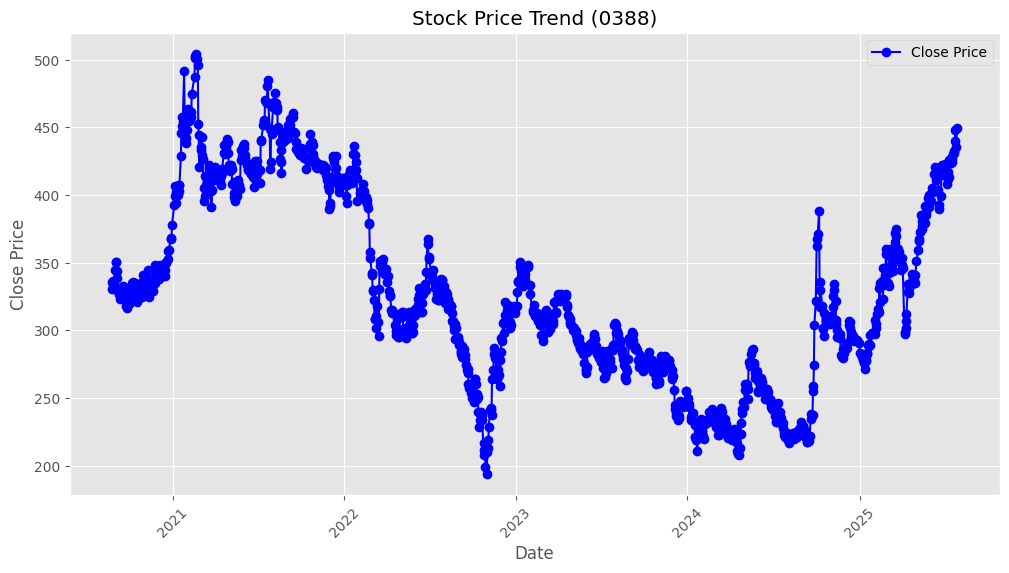

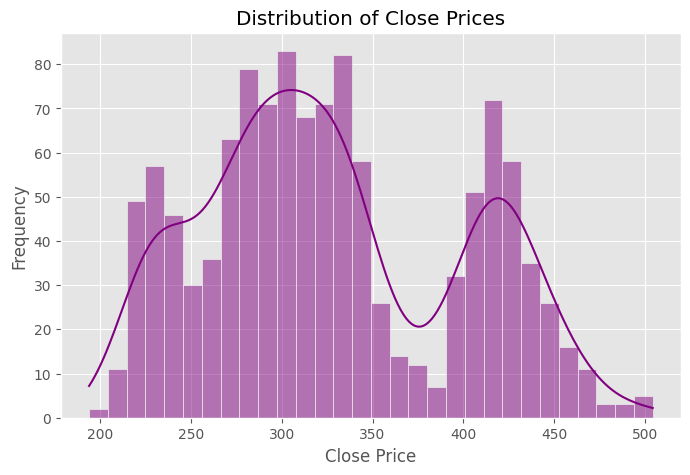

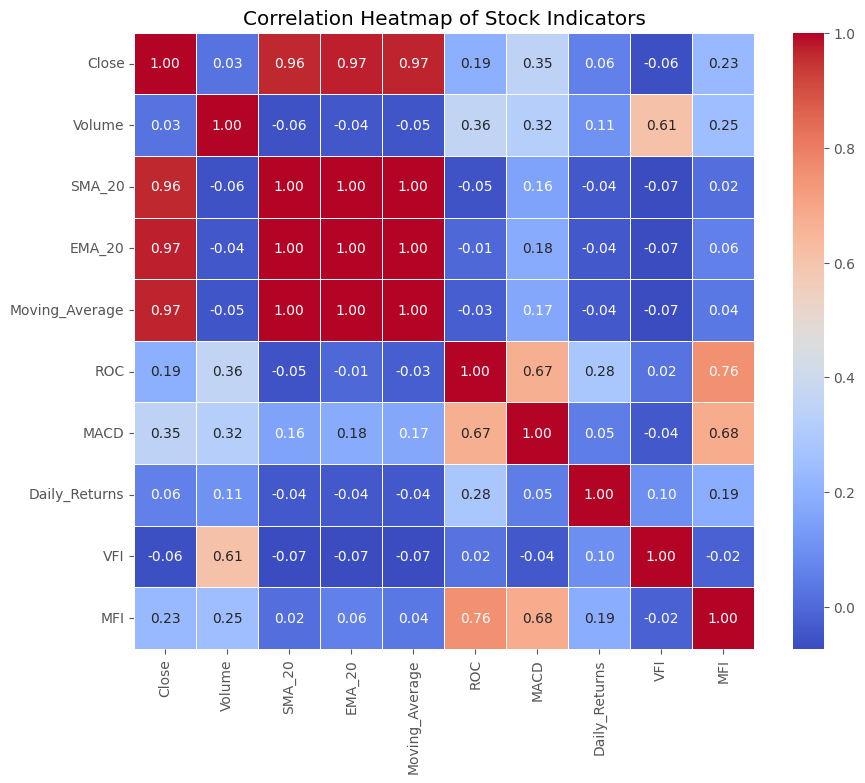

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a valid Matplotlib style
plt.style.use('ggplot')  

# --- 1. Time Series Plot (Stock Price Over Time) ---
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], marker='o', linestyle='-', color='blue', label='Close Price')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Stock Price Trend (0388)")
plt.legend()
plt.xticks(rotation=45)  # Rotate dates for readability
plt.show()

# --- 2. Histogram of Close Prices ---
plt.figure(figsize=(8, 5))
sns.histplot(df['Close'], bins=30, kde=True, color='purple')
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.title("Distribution of Close Prices")
plt.show()

# --- 3. Correlation Heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=["Date"]).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Stock Indicators")
plt.show()


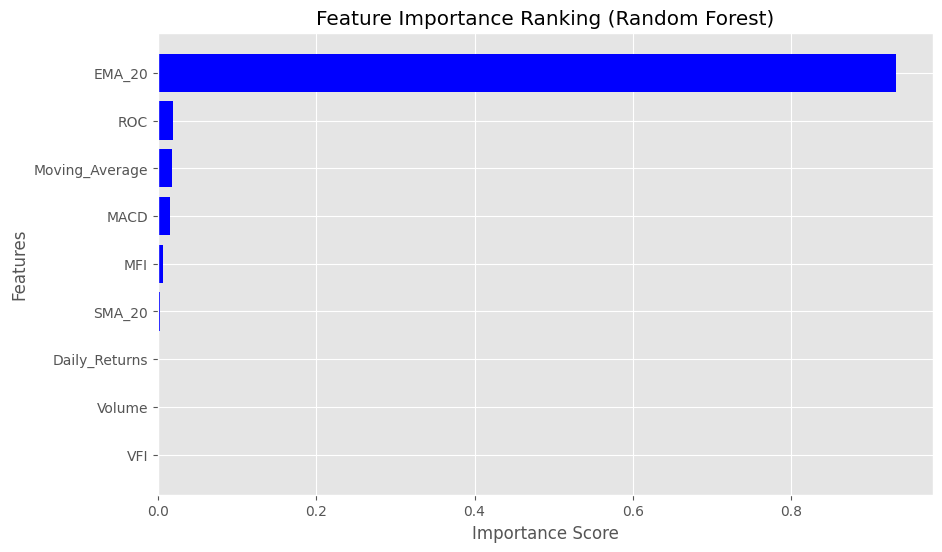


Feature Importance Ranking:
          Feature  Importance
2          EMA_20    0.931992
4             ROC    0.019044
3  Moving_Average    0.018282
5            MACD    0.015403
8             MFI    0.006898
1          SMA_20    0.002829
6   Daily_Returns    0.002163
0          Volume    0.002082
7             VFI    0.001307


In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- Load Cleaned Data ---
file_path = r"D:\Steven Documents\Project\HK options stock analysis\Stock data\0388_cleaned.xlsx"
df = pd.read_excel(file_path)

# --- Define Dependent (DV) and Independent Variables (IVs) ---
X = df.drop(columns=["Date", "Close"])  # IVs (exclude Date & Close)
y = df["Close"]  # DV

# --- Data Preprocessing ---
# Split data into training (70%) & testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the independent variables for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Train Random Forest Model ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# --- Get Feature Importance ---
feature_importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for feature importance ranking
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# --- Plot Feature Importance ---
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="blue")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance Ranking (Random Forest)")
plt.gca().invert_yaxis()  # Invert y-axis to show top features first
plt.show()

# Print ranked feature importance
print("\nFeature Importance Ranking:")
print(importance_df)


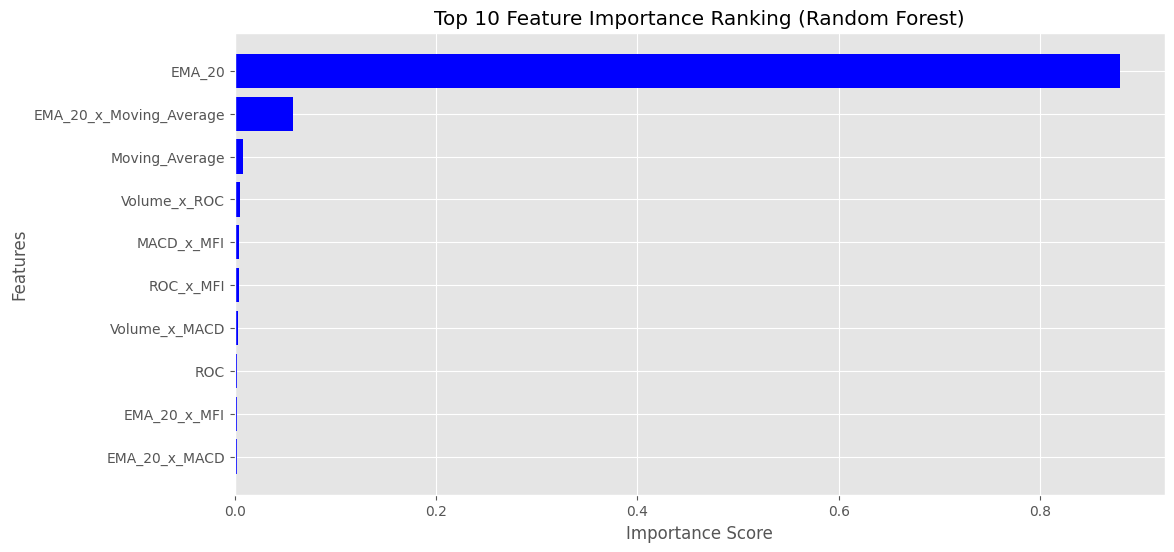


Feature Importance Ranking:
                           Feature  Importance
2                           EMA_20    0.879728
24         EMA_20_x_Moving_Average    0.057896
3                   Moving_Average    0.008434
12                    Volume_x_ROC    0.005475
41                      MACD_x_MFI    0.004669
38                       ROC_x_MFI    0.004239
13                   Volume_x_MACD    0.003242
4                              ROC    0.002624
29                    EMA_20_x_MFI    0.002469
26                   EMA_20_x_MACD    0.002462
23                    SMA_20_x_MFI    0.002337
20                   SMA_20_x_MACD    0.002198
34            Moving_Average_x_MFI    0.001997
25                    EMA_20_x_ROC    0.001985
35                      ROC_x_MACD    0.001806
30            Moving_Average_x_ROC    0.001651
5                             MACD    0.001607
19                    SMA_20_x_ROC    0.001479
31           Moving_Average_x_MACD    0.001446
18         SMA_20_x_Moving_Aver

In [6]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- Load Cleaned Data ---
file_path = r"D:\Steven Documents\Project\HK options stock analysis\Stock data\0388_cleaned.xlsx"
df = pd.read_excel(file_path)

# --- Define Dependent (DV) and Independent Variables (IVs) ---
X = df.drop(columns=["Date", "Close"])  # IVs (exclude Date & Close)
y = df["Close"]  # DV

# --- Generate All Possible Two-Variable Combinations ---
interaction_features = pd.DataFrame()
for var1, var2 in combinations(X.columns, 2):
    interaction_features[f"{var1}_x_{var2}"] = X[var1] * X[var2]  # Multiply two variables

# Combine original IVs with new interaction features
X_extended = pd.concat([X, interaction_features], axis=1)

# --- Data Preprocessing ---
# Split data into training (70%) & testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X_extended, y, test_size=0.3, random_state=42)

# Standardize features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Train Random Forest Model ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# --- Get Feature Importance ---
feature_importances = rf.feature_importances_
feature_names = X_extended.columns

# Create a DataFrame for feature importance ranking
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# --- Plot Feature Importance ---
plt.figure(figsize=(12, 6))
plt.barh(importance_df["Feature"].head(10), importance_df["Importance"].head(10), color="blue")  # Top 10 features
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance Ranking (Random Forest)")
plt.gca().invert_yaxis()  # Show top features first
plt.show()

# Print ranked feature importance
print("\nFeature Importance Ranking:")
print(importance_df)


d:\Program Files\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 400.03154693590477, tolerance: 327.4924410614877
  model = cd_fast.enet_coordinate_descent_gram(
d:\Program Files\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 547.7989705631626, tolerance: 327.4924410614877
  model = cd_fast.enet_coordinate_descent_gram(
d:\Program Files\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 637.3295030485606, tolerance: 327.4924410614877
  model = cd_fast.enet_coordinate_descent_gram(
d:\Program Files\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: Conve

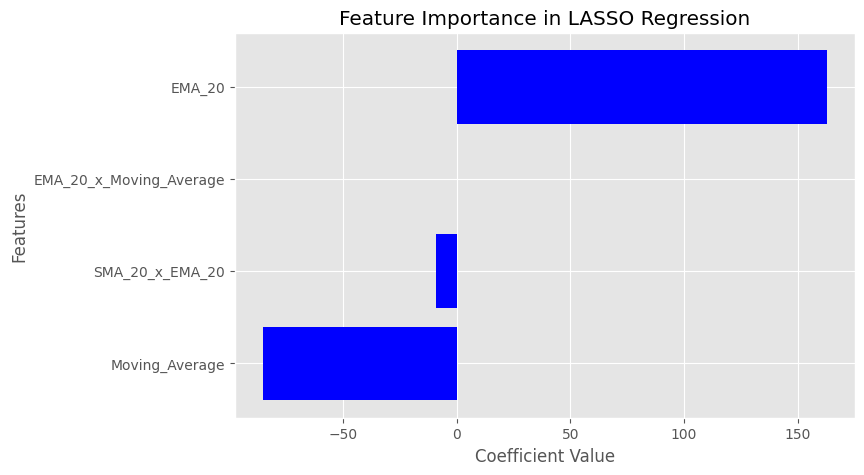


LASSO Regression Coefficients:
                   Feature  Coefficient
0                   EMA_20   162.721189
1  EMA_20_x_Moving_Average     0.000000
2          SMA_20_x_EMA_20    -9.286741
3           Moving_Average   -85.345996


In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- Load Cleaned Data ---
file_path = r"D:\Steven Documents\Project\HK options stock analysis\Stock data\0388_cleaned.xlsx"
df = pd.read_excel(file_path)

# --- Create Interaction Features ---
df["EMA_20_x_Moving_Average"] = df["EMA_20"] * df["Moving_Average"]
df["SMA_20_x_EMA_20"] = df["SMA_20"] * df["EMA_20"]

# --- Select Features for LASSO Regression ---
selected_features = ["EMA_20", "EMA_20_x_Moving_Average", "SMA_20_x_EMA_20", "Moving_Average"]
X = df[selected_features]  # Independent Variables
y = df["Close"]  # Target Variable

# --- Data Preprocessing ---
# Split data into training (70%) & testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Apply LASSO Regression ---
lasso = LassoCV(cv=5, random_state=42)  # Cross-validation with 5 folds
lasso.fit(X_train_scaled, y_train)

# --- Get Feature Coefficients (Importance) ---
feature_coefficients = pd.DataFrame({"Feature": selected_features, "Coefficient": lasso.coef_})
feature_coefficients = feature_coefficients.sort_values(by="Coefficient", ascending=False)

# --- Plot Feature Coefficients ---
plt.figure(figsize=(8, 5))
plt.barh(feature_coefficients["Feature"], feature_coefficients["Coefficient"], color="blue")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Feature Importance in LASSO Regression")
plt.gca().invert_yaxis()  # Show most important features first
plt.show()

# Print feature coefficients
print("\nLASSO Regression Coefficients:")
print(feature_coefficients)



LASSO Regression Feature Importance (% Contribution):
                   Feature  Coefficient  Relative_Importance_%
0                   EMA_20   162.721189              63.228563
1  EMA_20_x_Moving_Average     0.000000               0.000000
2          SMA_20_x_EMA_20    -9.286741               3.608548
3           Moving_Average   -85.345996              33.162889


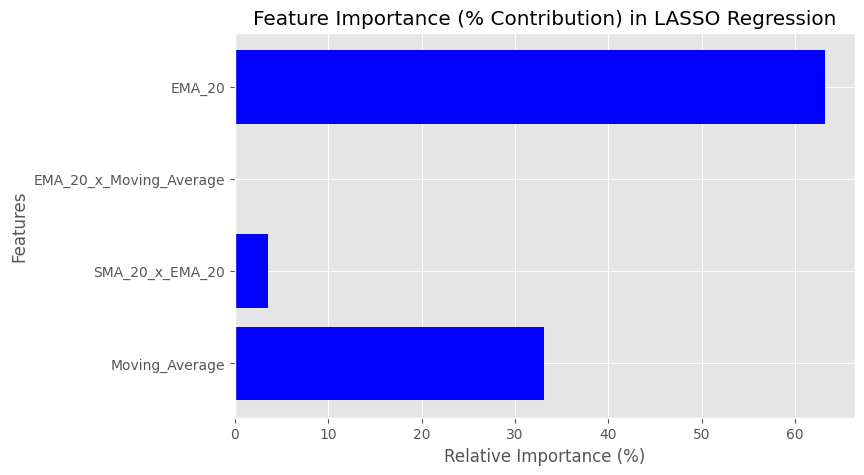

In [8]:
# Calculate relative importance percentage
feature_coefficients["Relative_Importance_%"] = (feature_coefficients["Coefficient"].abs() / 
                                                 feature_coefficients["Coefficient"].abs().sum()) * 100

# Print updated importance ranking with percentages
print("\nLASSO Regression Feature Importance (% Contribution):")
print(feature_coefficients)

# --- Plot Feature Importance in Percentage ---
plt.figure(figsize=(8, 5))
plt.barh(feature_coefficients["Feature"], feature_coefficients["Relative_Importance_%"], color="blue")
plt.xlabel("Relative Importance (%)")
plt.ylabel("Features")
plt.title("Feature Importance (% Contribution) in LASSO Regression")
plt.gca().invert_yaxis()  # Show most important features first
plt.show()


In [9]:
from sklearn.metrics import r2_score, mean_squared_error

# --- Make Predictions ---
y_pred = lasso.predict(X_test_scaled)

# --- Calculate R² Score ---
r2 = r2_score(y_test, y_pred)
print(f"\nR² Score (Explained Variance): {r2:.4f}")

# --- Calculate Mean Squared Error (MSE) ---
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")



R² Score (Explained Variance): 0.9554
Mean Squared Error (MSE): 216.4938


In [10]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- Load Cleaned Data ---
file_path = r"D:\Steven Documents\Project\HK options stock analysis\Stock data\0388_cleaned.xlsx"
df = pd.read_excel(file_path)

# --- Create Interaction Features ---
df["EMA_20_x_Moving_Average"] = df["EMA_20"] * df["Moving_Average"]
df["SMA_20_x_EMA_20"] = df["SMA_20"] * df["EMA_20"]

# --- Select Features for Model Training ---
selected_features = ["EMA_20", "EMA_20_x_Moving_Average", "SMA_20_x_EMA_20", "Moving_Average"]
X = df[selected_features]  # Independent Variables
y = df["Close"]  # Target Variable

# --- Data Preprocessing ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Train LASSO Model ---
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y)

# --- Automatically Fetch Today's SMA_20 Value ---
sma_today = df["SMA_20"].iloc[-1]  # Get most recent SMA_20 from dataset
ema_today = sma_today  # Approximate EMA_20 with SMA_20 trend
moving_avg_today = sma_today  # Approximate Moving_Average based on SMA_20

# Interaction features
ema_moving_avg_today = ema_today * moving_avg_today
sma_ema_today = sma_today * ema_today

# --- Create Feature Vector for Prediction & SCALE IT ---
user_input = np.array([[ema_today, ema_moving_avg_today, sma_ema_today, moving_avg_today]])
user_input_scaled = scaler.transform(user_input)

# --- Predict Close Price for Next 3 Days ---
forecast_days = 3
predictions = []
for i in range(forecast_days):
    predicted_close = lasso.predict(user_input_scaled)[0]
    predictions.append(predicted_close)
    sma_today *= 1.01  # Simulate slight daily movement for SMA
    user_input = np.array([[sma_today, sma_today * moving_avg_today, sma_today * ema_today, moving_avg_today]])
    user_input_scaled = scaler.transform(user_input)  # Ensure Scaling at Each Step

# --- Estimate Prediction Probability ---
pred_std = np.std(predictions)  # Approximate uncertainty using std dev
confidence_interval = pred_std * 1.96  # 95% confidence range

# Print Forecast Results
print("\nForecast for Next 3 Days (Auto-Fetched SMA_20):")
for i, pred in enumerate(predictions):
    print(f"Day {i+1}: Predicted Close Price = {pred:.2f} (±{confidence_interval:.2f})")

print("\nPrediction Probability: 95% Confidence Interval")
print(f"Range: ±{confidence_interval:.2f} around predicted values")



Forecast for Next 3 Days (Auto-Fetched SMA_20):
Day 1: Predicted Close Price = 427.12 (±16.30)
Day 2: Predicted Close Price = 437.25 (±16.30)
Day 3: Predicted Close Price = 447.49 (±16.30)

Prediction Probability: 95% Confidence Interval
Range: ±16.30 around predicted values


d:\Program Files\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 471.22182774951216, tolerance: 375.2324535602557
  model = cd_fast.enet_coordinate_descent_gram(
d:\Program Files\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 607.2156058807741, tolerance: 375.2324535602557
  model = cd_fast.enet_coordinate_descent_gram(
d:\Program Files\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 693.0484197831247, tolerance: 375.2324535602557
  model = cd_fast.enet_coordinate_descent_gram(
d:\Program Files\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: Conve